# Support Vector Regression Madel

In [13]:
# importing Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# import dataset
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values
y=y.reshape(len(y), 1) # feature scaling requires the dependent variable to be a matrix and not a vector



In [15]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)
print(X)
print(y)


[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]
[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


In [16]:
# Train the SVR model on the whole dataset
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X, y)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [17]:
# Predicting a new result
sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

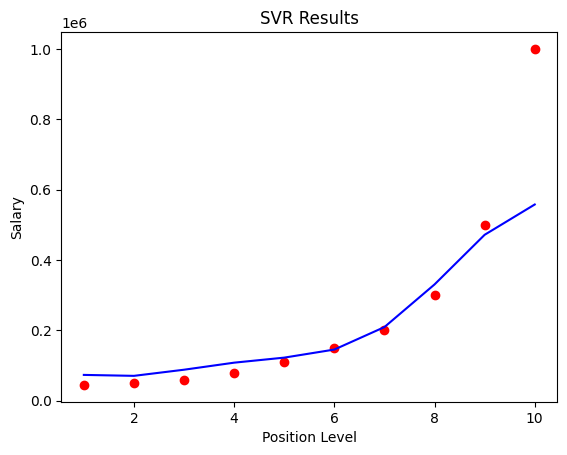

In [18]:
# Visualising the SVR results
# we apply invertransform to get the original values of X and y because we have feature scaled them
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regressor.predict(X).reshape(-1,1)), color = 'blue')
plt.title('SVR Results')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

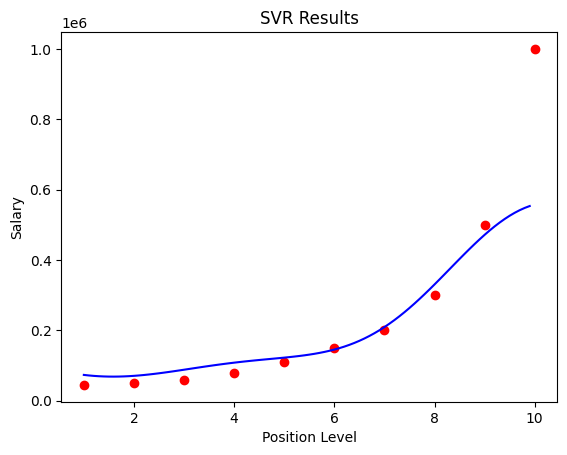

In [21]:
# Visualising the SVR results(for higher resolution and smoother curve)
# we create a grid of values with a distance of 0.1 between them
X_grid = np.arange(min(sc_X.inverse_transform(X).flatten()), max(sc_X.inverse_transform(X).flatten()), 0.1)

# we reshape it to make it a matrix
X_grid = X_grid.reshape((len(X_grid), 1)) 

plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)), color = 'blue')
plt.title('SVR Results')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()